In [25]:
def calculate_tip_positionx(
    sensor_length,
    stage_length,
    science_chamber_height,
    holder_height,
    stage_reading
):
    """
Calculate the tip position with respect the sc chamber geometric center.

Parameters
----------
sensor_length : float, Sensor Length, SenL.

stage_length : float, StageL.

science_chamber_height : float, SC.

holder_height : float, H.

stage_reading : float Reading value in the translation stage R.

Returns: float, tip position with respect the sc chamber geometric center.
"""

    # H' = H + R
    effective_holder_height = holder_height + stage_reading

    # A = SC/2 + CM + H'
    A = (
        science_chamber_height / 2
        + effective_holder_height
    )

    # tip = - (SenL + StageL ) + A
    tip_position = - sensor_length - stage_length + A

    return tip_position



# GEOMETRICAL PARAMETERS

SenL = 20.6375 # cm
StageL = 34.0 - 4.6 # cm
SC = 22.3012 # cm
H = 14.1 # cm
R = 0 # cm

tip = calculate_tip_positionx(
    sensor_length=SenL,
    stage_length=StageL,
    science_chamber_height=SC,
    holder_height=H,
    stage_reading= R
)

print(f"Posición del tip respecto al centro: {tip:.4f} cm")

Posición del tip respecto al centro: -24.7869 cm


In [51]:
from pathlib import Path
import pandas as pd

# FILES

INPUT_FILE = Path("Bx/MOT-Bfield-1ABX.csv")
OUTPUT_FILE = Path("CleanB/MOT-Bfield-1ABX-C.csv")

# GEOMETRICAL PARAMETERS

R_raw_lu = 1.4 # l.u.

# MAGNETIC FIELD BACKGROUND

B_background = -0.5  # G

# CALIBRATION PARAMETERS

calibration_slope = 1.0021824302575653
calibration_intercept = 0.33810939418853353  # cm We don't really use this

# READ AND CLEAN THE CSV

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"Could not find '{INPUT_FILE}'. "
        "Place the CSV in the same folder as this script "
        "or provide its full path."
    )

df = pd.read_csv(INPUT_FILE)

# Remove extra spaces from the original column names
df.columns = df.columns.str.strip()

# Expected columns in the original CSV
required_columns = ["z(lu)", "Bx(G)"]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}\n"
        f"Columns found in the CSV: {list(df.columns)}"
    )


df = df[required_columns].rename(
    columns={
        "z(lu)": "R_raw",
        "Bx(G)": "B_G",
    }
)

df["R_raw"] = pd.to_numeric(
    df["R_raw"],
    errors="coerce"
)

df["B_G"] = pd.to_numeric(
    df["B_G"],
    errors="coerce"
)

# Remove rows containing invalid or missing values
rows_before_cleaning = len(df)
df = df.dropna(subset=["R_raw", "B_G"]).copy()
rows_removed = rows_before_cleaning - len(df)


# Tip POSITION

df["z_geometry_cm"] = (tip + calibration_slope * (df["R_raw"] - R_raw_lu)
)

# Remove the magnetic-field background

df["B_corrected_G"] = df["B_G"] - B_background

# SORT, RESET INDEX, AND SAVE

df = df.sort_values("z_geometry_cm").reset_index(drop=True)

df_final = pd.DataFrame({
    "x(m)": df["z_geometry_cm"] / 100.0,
    "B(G)": df["B_corrected_G"]
})

df_final.to_csv(OUTPUT_FILE, index=False)


# SUMMARY

print("Cleaning and calibration completed.")
print(f"Rows in original file: {rows_before_cleaning}")
print(f"Invalid rows removed: {rows_removed}")
print(f"Valid rows saved: {len(df_final)}")
print(f"Output file: {OUTPUT_FILE.resolve()}")

print("\nFirst rows:")
print(df_final.head())


Cleaning and calibration completed.
Rows in original file: 254
Invalid rows removed: 0
Valid rows saved: 254
Output file: /Users/sofiapedraza/Documents/MOTcoils/MOT Data/MOT-Data-Bz/CleanB/MOT-Bfield-1ABX-C.csv

First rows:
       x(m)  B(G)
0 -0.246867   0.0
1 -0.241856   0.0
2 -0.236845  -0.1
3 -0.231834   0.2
4 -0.226823   0.0


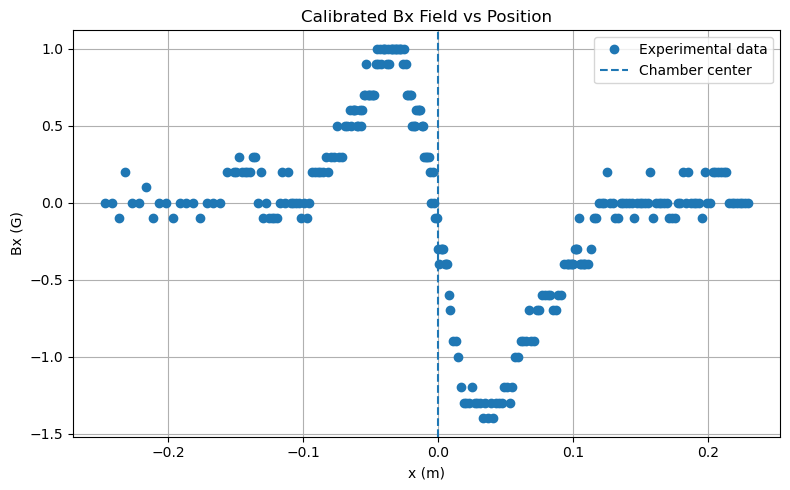

In [52]:
import matplotlib.pyplot as plt

# PLOT CLEAN CALIBRATED DATA

plt.figure(figsize=(8, 5))

plt.plot(
    df_final["x(m)"],
    df_final["B(G)"],
    marker="o",
    linestyle="",
    label="Experimental data"
)

# Chamber center
plt.axvline(
    x=0,
    linestyle="--",
    label="Chamber center"
)

plt.xlabel("x (m)")
plt.ylabel("Bx (G)")
plt.title("Calibrated Bx Field vs Position")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# THEORETICAL ANTI-HELMHOLTZ MODEL


mu0 = 4 * np.pi * 1e-7

# Coil parameters
R_coil = 0.0889       # m, inner radius
I_model = 1.0         # A, reference current used in the model
d_coil = 0.03730625   # m, distance from center to first winding
num_layers = 14
num_loops = 8
R_wire = 0.0028       # m


def one_loop_bz(z, radius, current, center_z):
    """
    Magnetic field on the axis of one circular loop.

    Returns the magnetic field in gauss.
    """

    z = np.asarray(z, dtype=float)

    B_tesla = (
        mu0
        * current
        * radius**2
        / (
            2
            * (
                radius**2
                + (z - center_z)**2
            )**1.5
        )
    )

    return B_tesla * 1e4  # tesla to gauss


def anti_helmholtz_bz(z):
    """
    Theoretical axial magnetic field produced by
    the anti-Helmholtz coil pair.

    Returns the magnetic field in gauss.
    """

    z = np.asarray(z, dtype=float)
    total_field = np.zeros_like(z)

    for layer in range(num_layers):
        for loop in range(num_loops):

            radius = R_coil + 2 * R_wire * loop

            upper_center = (
                d_coil
                + 2 * R_wire * layer
            )

            lower_center = (
                -d_coil
                - 2 * R_wire * layer
            )

            # Upper coil
            total_field += one_loop_bz(
                z=z,
                radius=radius,
                current=I_model,
                center_z=upper_center,
            )

            # Lower coil with opposite current
            total_field += one_loop_bz(
                z=z,
                radius=radius,
                current=-I_model,
                center_z=lower_center,
            )

    return total_field


# ============================================================
# FREE-PARAMETER MODEL
# ============================================================

def free_parameter_model(z, A, z0, B0):
    """
    A  : amplitude or scale factor
    z0 : horizontal position shift in meters
    B0 : constant magnetic-field background in gauss
    """

    return A * anti_helmholtz_bz(z - z0) + B0


# ============================================================
# EXPERIMENTAL DATA
# ============================================================

z_data = df_final["z(m)"].to_numpy(dtype=float)
B_data = df_final["B(G)"].to_numpy(dtype=float)

# Remove invalid values
valid = np.isfinite(z_data) & np.isfinite(B_data)

z_data = z_data[valid]
B_data = B_data[valid]


# ============================================================
# FREE-PARAMETER FIT
# ============================================================

# Initial guesses:
# A = 1
# z0 = 0 m
# B0 = median experimental field

initial_guess = [
    1.0,
    0.0,
    np.median(B_data),
]

# Allowed ranges for the parameters
lower_bounds = [
    -10.0,
    z_data.min(),
    -20.0,
]

upper_bounds = [
    10.0,
    z_data.max(),
    20.0,
]

fit_parameters, covariance = curve_fit(
    free_parameter_model,
    z_data,
    B_data,
    p0=initial_guess,
    bounds=(lower_bounds, upper_bounds),
    maxfev=100000,
)

A_fit, z0_fit, B0_fit = fit_parameters

# Parameter uncertainties
parameter_errors = np.sqrt(np.diag(covariance))

A_error, z0_error, B0_error = parameter_errors


# ============================================================
# FIT QUALITY
# ============================================================

B_fit_data = free_parameter_model(
    z_data,
    A_fit,
    z0_fit,
    B0_fit,
)

residuals = B_data - B_fit_data

sum_squared_residuals = np.sum(residuals**2)

total_sum_squares = np.sum(
    (B_data - np.mean(B_data))**2
)

R_squared = (
    1
    - sum_squared_residuals / total_sum_squares
)

RMSE = np.sqrt(
    np.mean(residuals**2)
)


# ============================================================
# PRINT RESULTS
# ============================================================

print("Free-parameter fit")
print("------------------")

print(
    f"A = {A_fit:.6f} "
    f"+/- {A_error:.6f}"
)

print(
    f"z0 = {z0_fit:.6f} "
    f"+/- {z0_error:.6f} m"
)

print(
    f"z0 = {100 * z0_fit:.4f} "
    f"+/- {100 * z0_error:.4f} cm"
)

print(
    f"B0 = {B0_fit:.6f} "
    f"+/- {B0_error:.6f} G"
)

print(f"R² = {R_squared:.6f}")
print(f"RMSE = {RMSE:.6f} G")


# ============================================================
# PLOT DATA AND FIT
# ============================================================

z_plot = np.linspace(
    z_data.min(),
    z_data.max(),
    1500,
)

B_plot = free_parameter_model(
    z_plot,
    A_fit,
    z0_fit,
    B0_fit,
)

plt.figure(figsize=(8, 5))

plt.scatter(
    z_data,
    B_data,
    s=20,
    label="Experimental data",
)

plt.plot(
    z_plot,
    B_plot,
    linewidth=2,
    label="Free-parameter fit",
)

plt.axvline(
    z0_fit,
    linestyle="--",
    label=f"Fitted center: z0 = {z0_fit:.4f} m",
)

plt.axhline(
    B0_fit,
    linestyle=":",
    label=f"Background: B0 = {B0_fit:.3f} G",
)

plt.xlabel("x (m)")
plt.ylabel("Bz (G)")
plt.title("Experimental Magnetic Field and Free-Parameter Fit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(8, 4))

plt.scatter(
    z_data,
    residuals,
    s=20,
)

plt.axhline(
    0,
    linestyle="--",
)

plt.xlabel("z (m)")
plt.ylabel("Measured - fit (G)")
plt.title("Fit Residuals")
plt.grid(True)
plt.tight_layout()
plt.show()

KeyError: 'z(m)'